# Hands-on Modul 3.5: Turbocharge LLM dengan vLLM

Dalam sistem produksi, kecepatan (*Latency*) dan kapasitas (*Throughput*) adalah uang.
Hari ini kita akan mempraktikkan **vLLM**, library yang menggunakan teknik **PagedAttention** untuk mengelola memori GPU secara efisien.

Kita juga akan menggunakan model yang sudah di-**Kuantisasi (AWQ)** untuk melihat betapa hematnya memori 4-bit.

In [1]:
# Instalasi vLLM (Engine Inference)
# Ini mungkin memakan waktu 1-2 menit karena mengompilasi kernel CUDA
!pip install vllm

# Install library pendukung
!pip install pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.1/472.1 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [1]:
import time
import pandas as pd

def benchmark_engine(llm, prompts, name):
    print(f"\n--- Benchmarking: {name} ---")

    # Catat waktu mulai
    start = time.time()

    # Generate (Batch Processing)
    # vLLM otomatis melakukan Continuous Batching di sini
    outputs = llm.generate(prompts)

    # Catat waktu selesai
    end = time.time()
    duration = end - start

    # Hitung Total Token
    total_tokens = sum([len(out.outputs[0].token_ids) for out in outputs])

    # Hitung Metrik (Throughput)
    tps = total_tokens / duration

    print(f"Selesai dalam: {duration:.2f} detik")
    print(f"Total Token  : {total_tokens}")
    print(f"Speed        : {tps:.2f} tokens/sec")

    return {"Engine": name, "TPS": tps}

# Siapkan Batch Prompts (Simulasi banyak user sekaligus)
test_prompts = [
    "Jelaskan secara singkat apa itu Black Hole.",
    "Tuliskan resep nasi goreng spesial.",
    "Siapa penemu lampu pijar?",
    "Buatkan puisi tentang hujan di sore hari.",
    "Apa perbedaan Python dan Java?",
    "Sebutkan 5 planet di tata surya."
] * 2 # Duplikasi jadi 12 request simultan

In [2]:
from vllm import LLM, SamplingParams
import torch
import gc

# Konfigurasi Sampling
sampling_params = SamplingParams(temperature=0.7, top_p=0.95, max_tokens=100)

# 1. Load Model Standard (FP16)
# Kita pakai Qwen 1.5 (0.5B) agar muat di Colab dan cepat demonya
# Di dunia nyata, ini bisa diganti Llama-3-8B
print("Memuat Model Standard (FP16)...")
llm_fp16 = LLM(model="Qwen/Qwen1.5-0.5B-Chat", dtype="float16", trust_remote_code=True)

# 2. Benchmark
res_fp16 = benchmark_engine(llm_fp16, test_prompts, "vLLM (FP16)")

# 3. Bersihkan Memori (PENTING di Colab)
# Kita harus menghapus model lama agar model baru muat di GPU
del llm_fp16
gc.collect()
torch.cuda.empty_cache()
print("Memori GPU dibersihkan.")

Memuat Model Standard (FP16)...
INFO 04-01 11:56:04 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'disable_log_stats': True, 'model': 'Qwen/Qwen1.5-0.5B-Chat'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

INFO 04-01 11:56:30 [model.py:533] Resolved architecture: Qwen2ForCausalLM
WARNING 04-01 11:56:30 [model.py:1920] Casting torch.bfloat16 to torch.float16.
INFO 04-01 11:56:30 [model.py:1582] Using max model len 32768
INFO 04-01 11:56:30 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-01 11:56:30 [vllm.py:775] Asynchronous scheduling is enabled.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

WARNING 04-01 11:56:34 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 04-01 12:00:23 [llm.py:391] Supported tasks: ['generate']

--- Benchmarking: vLLM (FP16) ---
WARNING 04-01 12:00:24 [model.py:1376] Default vLLM sampling parameters have been overridden by the model's `generation_config.json`: `{'repetition_penalty': 1.1, 'top_p': 0.8}`. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.


Rendering prompts:   0%|          | 0/12 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/12 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Selesai dalam: 4.47 detik
Total Token  : 12
Speed        : 2.69 tokens/sec
Memori GPU dibersihkan.


In [3]:
# 1. Load Model Quantized (AWQ)
# Perhatikan parameter quantization="awq"
print("\nMemuat Model Quantized (AWQ 4-bit)...")
llm_awq = LLM(
    model="Qwen/Qwen1.5-0.5B-Chat-AWQ",
    quantization="awq",
    dtype="float16", # Komputasi tetap FP16
    trust_remote_code=True,
    gpu_memory_utilization=0.8 # Kurangi alokasi memori GPU untuk menghindari OOM
)

# 2. Benchmark
res_awq = benchmark_engine(llm_awq, test_prompts, "vLLM (AWQ)")


Memuat Model Quantized (AWQ 4-bit)...
INFO 04-01 12:06:04 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'quantization': 'awq', 'model': 'Qwen/Qwen1.5-0.5B-Chat-AWQ'}


config.json:   0%|          | 0.00/839 [00:00<?, ?B/s]

INFO 04-01 12:06:06 [model.py:533] Resolved architecture: Qwen2ForCausalLM
INFO 04-01 12:06:06 [model.py:1582] Using max model len 32768
INFO 04-01 12:06:06 [awq_marlin.py:166] Detected that the model can run with awq_marlin, however you specified quantization=awq explicitly, so forcing awq. Use quantization=awq_marlin for faster inference
INFO 04-01 12:06:06 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/205 [00:00<?, ?B/s]

INFO 04-01 12:07:32 [llm.py:391] Supported tasks: ['generate']

--- Benchmarking: vLLM (AWQ) ---


Rendering prompts:   0%|          | 0/12 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/12 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Selesai dalam: 0.55 detik
Total Token  : 12
Speed        : 21.77 tokens/sec


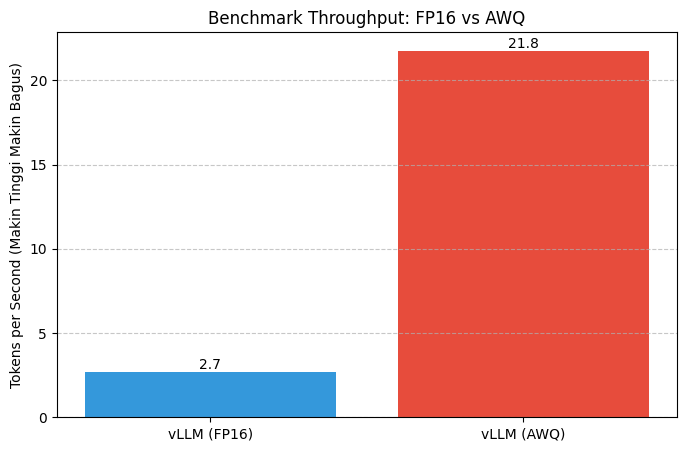

In [4]:
import matplotlib.pyplot as plt

# Bandingkan Hasil
df = pd.DataFrame([res_fp16, res_awq])

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(df["Engine"], df["TPS"], color=['#3498db', '#e74c3c'])
plt.title("Benchmark Throughput: FP16 vs AWQ")
plt.ylabel("Tokens per Second (Makin Tinggi Makin Bagus)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tampilkan angka
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}', ha='center', va='bottom')

plt.show()

### 💡 Analisis Hasil

Dari grafik di atas, Anda bisa melihat karakteristik performa:

1.  **vLLM (FP16):** Sudah sangat cepat karena menggunakan *PagedAttention* dan *Continuous Batching*.
2.  **vLLM (AWQ):** Biasanya memiliki *Throughput* yang setara atau sedikit lebih rendah/tinggi (tergantung bottleneck).
    * *Keuntungan Utama AWQ:* Bukan selalu di kecepatan, tapi di **MEMORI**. Model AWQ memakan VRAM jauh lebih sedikit (hingga 3x lipat).
    * *Implikasi:* Dengan AWQ, Anda bisa menaikkan *batch size* (jumlah user simultan) jauh lebih banyak sebelum GPU *crash*.

**Tugas Eksperimen:**
Cobalah perbanyak jumlah prompt di `test_prompts` (kalikan 10) dan lihat apakah model FP16 mengalami *OOM (Out of Memory)* lebih dulu dibandingkan model AWQ.